# Term Deposit Marketing 2
## Introduction
- Prior to reading this notebook, see **notebook_1.ipynb** for **Data wrangling, Exploratory data analysis, Data visualization, Model creation and Model evaluation**.
- As a reminder, **CatBoostClassifier, LGBMClassifier, RandomForestClassifier, XGBClassifier and DecisionTreeClassifier** all surpassed the goal of **81% test accuracy** with **CatBoostClassifier and RandomForestClassifier** producing the best results of **~87%** test accuracy each.
- These models have been saved in the models folder of this project repository.
- This notebook will tackle **Feature Importance** and **Customer Segmentation**.

### Libraries

In [1]:
# Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Warnings
from warnings import filterwarnings
filterwarnings("ignore")

# Sklearn
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, RFECV
from sklearn.inspection import permutation_importance
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

### Helper function(s)

In [2]:
# Shared helpers live in utils.py at the project root
from utils import barrier,bold,print_bold,print_uniques,na_random_fill,save_model,load_model,save_model_dropped,load_model_dropped

## Data

In [3]:
df = pd.read_csv("data_raw.csv")

# Replace "unknown" sentinel values with NaN, then random-impute
df.replace("unknown", np.nan, inplace=True)
df["job"] = na_random_fill(df["job"])
df["education"] = na_random_fill(df["education"])
df["contact"] = na_random_fill(df["contact"])

# Label encoding for object dtypes
features = df.select_dtypes("object").columns
df_enc = df.copy()
df_enc[features] = df_enc[features].apply(
    lambda ser: pd.Series(LabelEncoder().fit_transform(ser), index=ser.index)
)

RANDOM_STATE = 42

# Full-balanced dataset (used by clustering visualisations only)
ones_full = df_enc[df_enc["y"] == 1]
zeros_full = df_enc[df_enc["y"] == 0].sample(n=len(ones_full), random_state=RANDOM_STATE)
df_enc_balanced = (
    pd.concat([ones_full, zeros_full])
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)
X = df_enc_balanced.drop("y", axis=1)
y = df_enc_balanced["y"]

# Stratified split BEFORE balancing so the test fold keeps the natural
# class distribution; only the training fold is under-sampled.
df_train_enc, df_test_enc = train_test_split(
    df_enc,
    test_size=0.30,
    stratify=df_enc["y"],
    random_state=RANDOM_STATE,
)
ones = df_train_enc[df_train_enc["y"] == 1]
zeros = df_train_enc[df_train_enc["y"] == 0].sample(n=len(ones), random_state=RANDOM_STATE)
df_train_balanced = (
    pd.concat([ones, zeros])
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

X_train = df_train_balanced.drop("y", axis=1)
y_train = df_train_balanced["y"]
X_test = df_test_enc.drop("y", axis=1)
y_test = df_test_enc["y"]

features = X_train.columns


### Important note
- We did not perform one-hot encoding because we want each feature to be evaluated holistically without becoming too granular.

## Models

In [4]:
# Load saved models
DTC_feat_imp = load_model("DTC.pkl")
RF_feat_imp = load_model("RF.pkl")
XGB_feat_imp = load_model("XGB.pkl")
CAT_feat_imp = load_model("CAT.pkl")
LGBM_feat_imp = load_model("LGBM.pkl")

models_ = [DTC_feat_imp, RF_feat_imp, XGB_feat_imp, CAT_feat_imp, LGBM_feat_imp]
models = [clone(model) for model in models_]

for model in models:
    names = model.__class__.__name__
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print_bold(names + ":" )
    print(f"Test accuracy: {acc}")
    barrier()

DecisionTreeClassifier:
Test accuracy: 0.8545833333333334

 <<< -------------------------------------------------- >>> 

RandomForestClassifier:
Test accuracy: 0.855

 <<< -------------------------------------------------- >>> 

XGBClassifier:
Test accuracy: 0.8556666666666667

 <<< -------------------------------------------------- >>> 

CatBoostClassifier:
Test accuracy: 0.8695

 <<< -------------------------------------------------- >>> 

LGBMClassifier:
Test accuracy: 0.866

 <<< -------------------------------------------------- >>> 



In [5]:
# A reminder of the different dataframes we have created so far
display(df.head())
barrier()
display(df_enc.head())
barrier()
display(df_enc_balanced.head())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,cellular,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,cellular,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,cellular,5,may,76,1,no
3,47,blue-collar,married,primary,no,1506,yes,no,cellular,5,may,92,1,no
4,33,admin,single,tertiary,no,1,no,no,cellular,5,may,198,1,no



 <<< -------------------------------------------------- >>> 



,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,4,1,2,0,2143,1,0,0,5,8,261,1,0
1,44,9,2,1,0,29,1,0,0,5,8,151,1,0
2,33,2,1,1,0,2,1,1,0,5,8,76,1,0
3,47,1,1,0,0,1506,1,0,0,5,8,92,1,0
4,33,0,2,2,0,1,0,0,0,5,8,198,1,0



 <<< -------------------------------------------------- >>> 



,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,39,7,0,1,0,0,1,0,0,13,0,1006,2,1
1,60,4,1,2,0,2281,0,0,0,5,3,230,2,1
2,33,6,2,2,0,61,0,0,0,19,1,836,3,1
3,30,8,2,2,0,228,1,0,0,13,8,314,2,1
4,32,9,2,2,0,4665,1,0,0,21,8,860,2,1


In [6]:
# A reminder of the different dataframes we have created so far
display(df.info())
barrier()
display(df_enc.info())
barrier()
display(df_enc_balanced.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


None


 <<< -------------------------------------------------- >>> 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        40000 non-null  int64
 1   job        40000 non-null  int64
 2   marital    40000 non-null  int64
 3   education  40000 non-null  int64
 4   default    40000 non-null  int64
 5   balance    40000 non-null  int64
 6   housing    40000 non-null  int64
 7   loan       40000 non-null  int64
 8   contact    40000 non-null  int64
 9   day        40000 non-null  int64
 10  month      40000 non-null  int64
 11  duration   40000 non-null  int64
 12  campaign   40000 non-null  int64
 13  y          40000 non-null  int64
dtypes: int64(14)
memory usage: 4.3 MB


None


 <<< -------------------------------------------------- >>> 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5792 entries, 0 to 5791
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        5792 non-null   int64
 1   job        5792 non-null   int64
 2   marital    5792 non-null   int64
 3   education  5792 non-null   int64
 4   default    5792 non-null   int64
 5   balance    5792 non-null   int64
 6   housing    5792 non-null   int64
 7   loan       5792 non-null   int64
 8   contact    5792 non-null   int64
 9   day        5792 non-null   int64
 10  month      5792 non-null   int64
 11  duration   5792 non-null   int64
 12  campaign   5792 non-null   int64
 13  y          5792 non-null   int64
dtypes: int64(14)
memory usage: 633.6 KB


None

## Feature importance
### Methodology
There are many techniques for evaluating feature importance. The best method will ultimately depend on our data and our model(s). We will cover a few methods here, namely:
1. Using model attributes
2. Permutation feature importance
3. Recursive feature elimination (RFE)

**NOTE:**
- We will re-import the data and perform all transformations except one-hot encoding. This will keep the number of features to the initial 14 and make the outputs more interpretable.
    - This will also involve creating new training and testing datasets.
    - We will also clone the models (which preserves all internal parameters) to create deep copies and refit the data so the feature importances are consistent with the original features as opposed to the expanded feature list that was created following one-hot encoding.
- Results of all methods will be collated in the **Inference** sub-section of this Feature importance section.

**NOTE:**
As a reminder from the introduction, the features break down as follows:
- age: age of customer (numeric)
- job: type of job (categorical)
- marital: marital status (categorical)
- education (categorical)
- default: has credit in default? (binary)
- balance: average yearly balance, in euros (numeric)
- housing: has a housing loan? (binary)
- loan: has personal loan? (binary)
- contact: contact communication type (categorical)
- day: last contact day of the month (numeric)
- month: last contact month of year (categorical)
- duration: last contact duration, in seconds (numeric)
- campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
- **Output (desired target)**:
    - y: has the client subscribed to a term deposit? (binary)

### Using model attributes
- Certain methods of feature importance require the model to have a `coef_` or `feature_importances_` attribute.
- The coefficients (from `coef_`) indicate which features get a heavier emphasis in making predictions while `feature_importances_` more directly indicates the weight given to each feature when making predictions.
- Tree based methods usually have the `feature_importances_` attribute.
- We will write code to check for and plot these values.

In [7]:
# Check for attributes
def attr_checker(model):
    print(f"feature_importances_ : {hasattr(model, 'feature_importances_')}")
    print(f"coef_ : {hasattr(model, 'coef_')}")

# Plot model coefficients
def feat_import(model):
    importance = model.coef_
    for i, v in zip(features, importance):
        print(f"Feature: {i}, Score: {v}")
    barrier()
    plt.bar(features, importance)
    plt.xlabel("Features")
    plt.ylabel("Importance")
    plt.title("Importance vs Features")
    plt.xticks(rotation=-90)
    plt.show()

# Plot tree model feature importances
def feat_import_tree(model):
    importance = model.feature_importances_
    for i, v in zip(features, importance):
        print(f"Feature: {i}, Score: {v}")
    plt.bar(features, importance)
    plt.xlabel("Features")
    plt.ylabel("Importance")
    plt.title("Importance vs Features")
    plt.xticks(rotation=-90)
    plt.show()

# Plot tree model feature importances - alternate
def feat_import_tree_2(model):
    Importance = pd.DataFrame({"Importance": model.feature_importances_*100}, index=X_train.columns)
    Importance.sort_values(by="Importance", axis=0, ascending=True).plot(kind="barh", color="r")
    plt.xlabel("Feature which should be focusing more on")
    plt.gca().legend_ = None
    plt.show()

In [8]:
# Check for coef_ and feature_importances_ attributes
for model in models:
    print_bold(model.__class__.__name__)
    attr_checker(model)
    barrier()

DecisionTreeClassifier
feature_importances_ : True
coef_ : False

 <<< -------------------------------------------------- >>> 

RandomForestClassifier
feature_importances_ : True
coef_ : False

 <<< -------------------------------------------------- >>> 

XGBClassifier
feature_importances_ : True
coef_ : False

 <<< -------------------------------------------------- >>> 

CatBoostClassifier
feature_importances_ : True
coef_ : False

 <<< -------------------------------------------------- >>> 

LGBMClassifier
feature_importances_ : True
coef_ : False

 <<< -------------------------------------------------- >>> 



**NOTE:**
- All models have the `feature_importances_` attribute but none have the `coef_` attribute.

In [9]:
# Model classes and features
display([model.__class__.__name__ for model in models])
barrier()
display(features)

['DecisionTreeClassifier',
 'RandomForestClassifier',
 'XGBClassifier',
 'CatBoostClassifier',
 'LGBMClassifier']


 <<< -------------------------------------------------- >>> 



Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign'],
      dtype='object')

DecisionTreeClassifier
Feature: age, Score: 0.04786942661208762
Feature: job, Score: 0.006650885106908176
Feature: marital, Score: 0.002330976290713468
Feature: education, Score: 0.011302749007200187
Feature: default, Score: 0.0
Feature: balance, Score: 0.04112754200062237
Feature: housing, Score: 0.046436918791688264
Feature: loan, Score: 0.0016262313106210505
Feature: contact, Score: 0.0027115052744467374
Feature: day, Score: 0.06678287683873796
Feature: month, Score: 0.1306941704090739
Feature: duration, Score: 0.6321103588261
Feature: campaign, Score: 0.010356359531800235


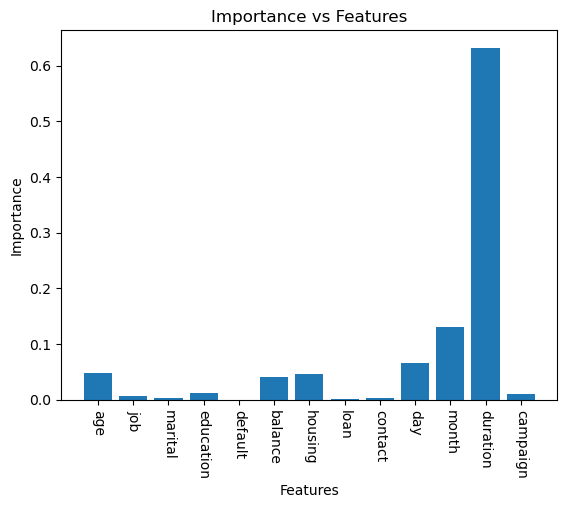


 <<< -------------------------------------------------- >>> 

RandomForestClassifier
Feature: age, Score: 0.0476362066744249
Feature: job, Score: 0.011089222092361484
Feature: marital, Score: 0.004450469077686908
Feature: education, Score: 0.011636720763142774
Feature: default, Score: 0.0002500316464886074
Feature: balance, Score: 0.04093401509512358
Feature: housing, Score: 0.041846126070745344
Feature: loan, Score: 0.0028532476408331775
Feature: contact, Score: 0.002961538586324527
Feature: day, Score: 0.05517676970392741
Feature: month, Score: 0.10052398982923494
Feature: duration, Score: 0.6706391266503092
Feature: campaign, Score: 0.010002536169397168


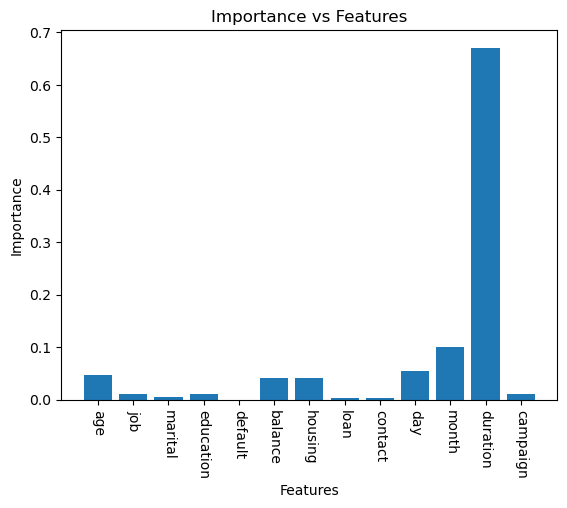


 <<< -------------------------------------------------- >>> 

XGBClassifier
Feature: age, Score: 0.038969941437244415
Feature: job, Score: 0.013251496478915215
Feature: marital, Score: 0.020015669986605644
Feature: education, Score: 0.039527345448732376
Feature: default, Score: 0.0
Feature: balance, Score: 0.029111724346876144
Feature: housing, Score: 0.1670311838388443
Feature: loan, Score: 0.028979578986763954
Feature: contact, Score: 0.012180198915302753
Feature: day, Score: 0.04275507852435112
Feature: month, Score: 0.1280093491077423
Feature: duration, Score: 0.46570703387260437
Feature: campaign, Score: 0.01446143165230751


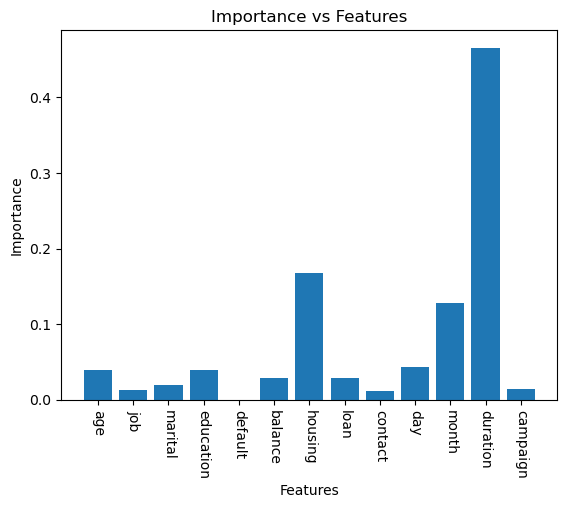


 <<< -------------------------------------------------- >>> 

CatBoostClassifier
Feature: age, Score: 6.085293026242246
Feature: job, Score: 3.7540515567792165
Feature: marital, Score: 2.1104058861653217
Feature: education, Score: 2.8610655752566103
Feature: default, Score: 0.1513969599868866
Feature: balance, Score: 7.030123353620909
Feature: housing, Score: 4.529742261963941
Feature: loan, Score: 1.1746675385821537
Feature: contact, Score: 0.5036476576834912
Feature: day, Score: 12.94833528460759
Feature: month, Score: 23.331684226009223
Feature: duration, Score: 31.777599549997223
Feature: campaign, Score: 3.741987123105177


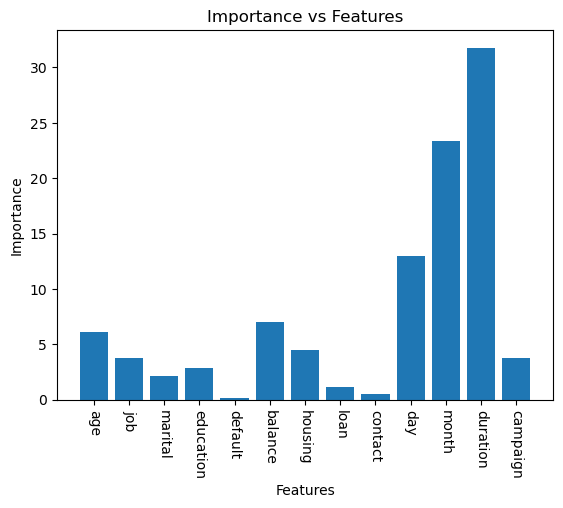


 <<< -------------------------------------------------- >>> 

LGBMClassifier
Feature: age, Score: 398
Feature: job, Score: 110
Feature: marital, Score: 65
Feature: education, Score: 86
Feature: default, Score: 14
Feature: balance, Score: 460
Feature: housing, Score: 67
Feature: loan, Score: 33
Feature: contact, Score: 35
Feature: day, Score: 518
Feature: month, Score: 564
Feature: duration, Score: 765
Feature: campaign, Score: 96


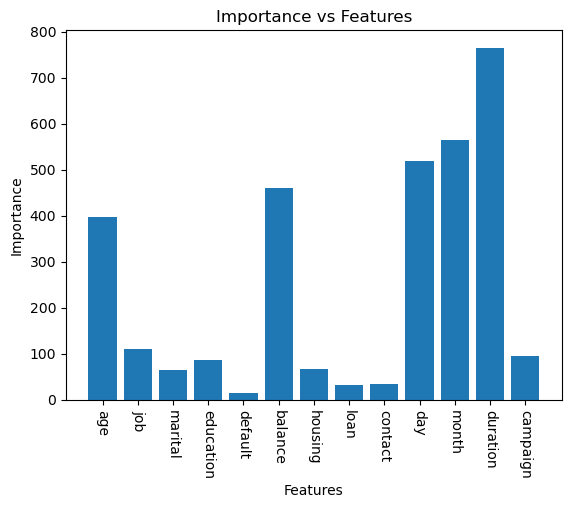


 <<< -------------------------------------------------- >>> 



In [10]:
# Using model attributes
for model in models:
    print_bold(model.__class__.__name__)
    feat_import_tree(model)
    barrier()

### Permutation feature importance
- Permutation feature importance is a model inspection technique that measures the contribution of each feature to a fitted model’s statistical performance on a given tabular dataset.
- This technique is particularly useful for non-linear or opaque estimators, and involves randomly shuffling the values of a single feature and observing the resulting degradation of the model’s score.
- By breaking the relationship between the feature and the target, we determine how much the model relies on such particular feature. [1].

**Ref:**
1. https://scikit-learn.org/stable/modules/permutation_importance.html

In [11]:
# Permutation feature importance
def feat_import_perm(model):
    results = permutation_importance(model, X_train, y_train, scoring="accuracy")
    importance = results.importances_mean
    for i, v in zip(features, importance):
        print(f"Feature: {i}, Score: {v}")
    plt.bar(features, importance)
    plt.xlabel("Features")
    plt.ylabel("Importance")
    plt.title("Importance vs Features")
    plt.xticks(rotation=-90)
    plt.show()

DecisionTreeClassifier
Feature: age, Score: 0.029107054760730167
Feature: job, Score: 0.004341391218549618
Feature: marital, Score: 0.002417365564874219
Feature: education, Score: 0.010705476073014308
Feature: default, Score: 0.0
Feature: balance, Score: 0.025900345337937836
Feature: housing, Score: 0.018253576714356234
Feature: loan, Score: 0.0009373458312777582
Feature: contact, Score: 0.00039467192895905614
Feature: day, Score: 0.04509126788357183
Feature: month, Score: 0.06956092747903309
Feature: duration, Score: 0.3396645288603848
Feature: campaign, Score: 0.0046373951652689096


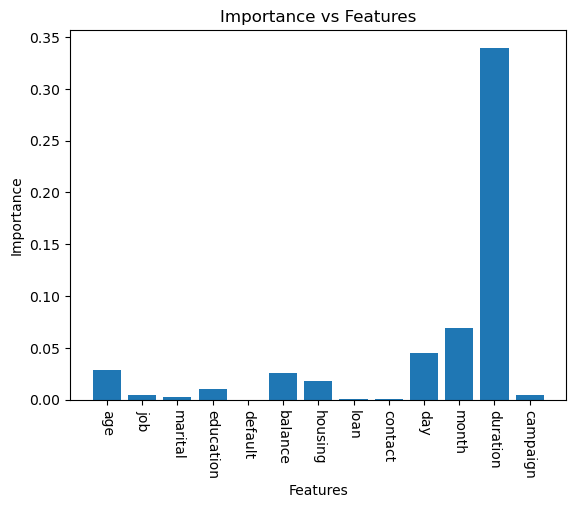


 <<< -------------------------------------------------- >>> 

RandomForestClassifier
Feature: age, Score: 0.02234829797730642
Feature: job, Score: 0.003502713369511623
Feature: marital, Score: 0.002664035520473629
Feature: education, Score: 0.006512086827824426
Feature: default, Score: 0.0
Feature: balance, Score: 0.014652195362604847
Feature: housing, Score: 0.02624568327577701
Feature: loan, Score: 0.0008880118401578763
Feature: contact, Score: -0.00014800197335964604
Feature: day, Score: 0.029797730636408514
Feature: month, Score: 0.06053280710409477
Feature: duration, Score: 0.33591514553527385
Feature: campaign, Score: 0.002417365564874219


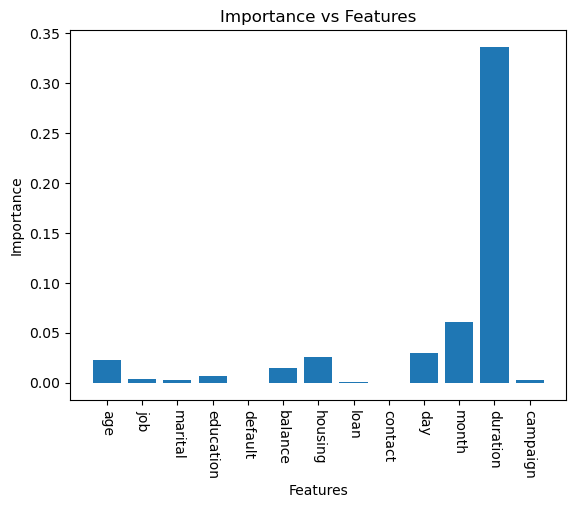


 <<< -------------------------------------------------- >>> 

XGBClassifier
Feature: age, Score: 0.011889491859891455
Feature: job, Score: 0.0015293537247163425
Feature: marital, Score: 0.0015293537247163425
Feature: education, Score: 0.0021213616181549265
Feature: default, Score: 0.0
Feature: balance, Score: 0.008288110508140068
Feature: housing, Score: 0.02022693635915147
Feature: loan, Score: 9.866798223976403e-05
Feature: contact, Score: 9.866798223976403e-05
Feature: day, Score: 0.02328564380858409
Feature: month, Score: 0.05811544153922055
Feature: duration, Score: 0.32481499753330045
Feature: campaign, Score: 0.0002466699555994101


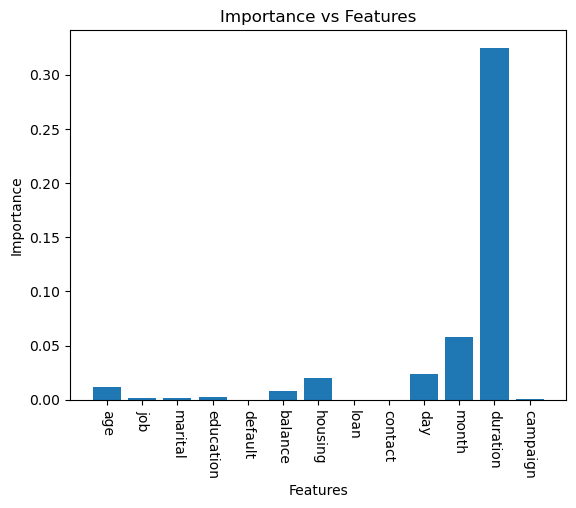


 <<< -------------------------------------------------- >>> 

CatBoostClassifier
Feature: age, Score: 0.02160828811050821
Feature: job, Score: 0.012974839664528882
Feature: marital, Score: 0.0062654168722250155
Feature: education, Score: 0.00976813024173664
Feature: default, Score: 9.866798223976403e-05
Feature: balance, Score: 0.025111001480019747
Feature: housing, Score: 0.02461766156882097
Feature: loan, Score: 0.0019240256536753985
Feature: contact, Score: 0.0022200296003946907
Feature: day, Score: 0.07242229896398625
Feature: month, Score: 0.1159348791317218
Feature: duration, Score: 0.3568820917612235
Feature: campaign, Score: 0.010606808090774588


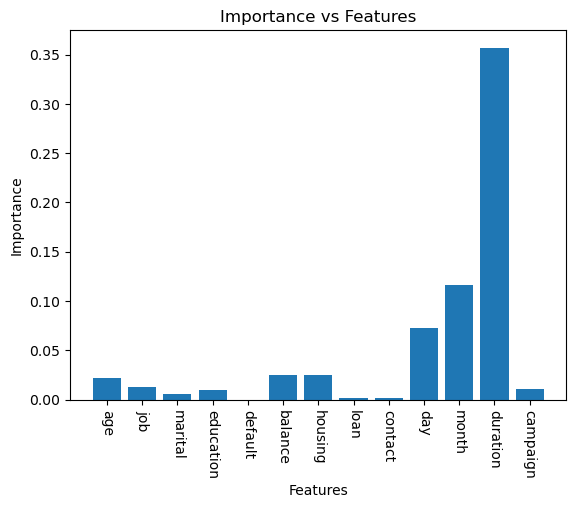


 <<< -------------------------------------------------- >>> 

LGBMClassifier
Feature: age, Score: 0.014158855451406027
Feature: job, Score: 0.005328071040947258
Feature: marital, Score: 0.003996053280710443
Feature: education, Score: 0.0049333991119882015
Feature: default, Score: 0.00014800197335964604
Feature: balance, Score: 0.014652195362604847
Feature: housing, Score: 0.01420818944252591
Feature: loan, Score: 0.0030093734583128027
Feature: contact, Score: 0.0005426739023187022
Feature: day, Score: 0.05569807597434635
Feature: month, Score: 0.09220522940305872
Feature: duration, Score: 0.3418352244696596
Feature: campaign, Score: 0.006216082881105134


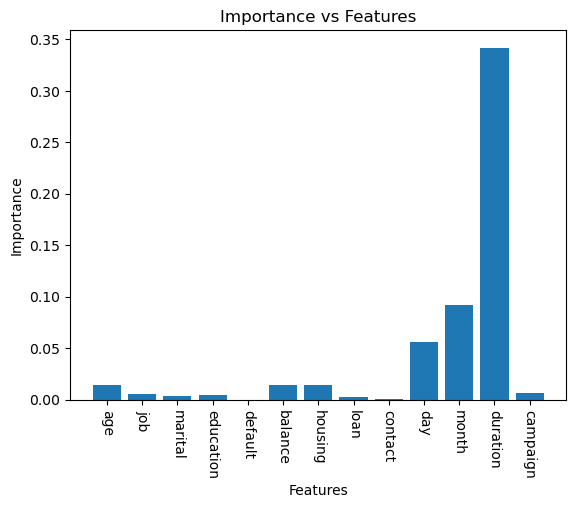


 <<< -------------------------------------------------- >>> 



In [12]:
# Permutation feature importances
for model in models:
    print_bold(model.__class__.__name__)
    feat_import_perm(model)
    barrier()

### Recursive feature elimination (RFE)
- The goal of recursive feature elimination (RFE) is to select features by recursively considering smaller and smaller sets of features.
- First, the estimator is trained on the initial set of features and the importance of each feature is obtained through the model attributes.
- Then, the least important features are pruned from current set of features.
- That procedure is recursively repeated on the pruned set until the desired number of features to select is eventually reached [1].

**Ref:**
1. https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html

In [13]:
# RFE
for model in models:
    print_bold(model.__class__.__name__)
    rfe = RFE(model, n_features_to_select=1)
    rfe.fit(X_train, y_train)
    for i, j in (sorted(zip(rfe.ranking_ , features), key=lambda item:item[0])):
        print(i, j)
    barrier()

DecisionTreeClassifier
1 duration
2 month
3 day
4 age
5 balance
6 housing
7 education
8 job
9 campaign
10 marital
11 contact
12 loan
13 default

 <<< -------------------------------------------------- >>> 

RandomForestClassifier
1 duration
2 month
3 day
4 age
5 housing
6 balance
7 education
8 job
9 campaign
10 marital
11 loan
12 contact
13 default

 <<< -------------------------------------------------- >>> 

XGBClassifier
1 duration
2 housing
3 month
4 day
5 education
6 age
7 balance
8 loan
9 marital
10 campaign
11 job
12 contact
13 default

 <<< -------------------------------------------------- >>> 

CatBoostClassifier
1 month
2 duration
3 day
4 balance
5 age
6 housing
7 campaign
8 job
9 education
10 marital
11 loan
12 contact
13 default

 <<< -------------------------------------------------- >>> 

LGBMClassifier
1 duration
2 day
3 month
4 balance
5 age
6 job
7 campaign
8 education
9 housing
10 marital
11 contact
12 loan
13 default

 <<< -------------------------------------------

### RFE cross validation (RFECV)
- RFE cross validation (RFECV) combines the RFE above with cross validation and gives the best combination of features that maximizes the accuracy with the smallest possible number of features.
- The number of features selected is tuned automatically by fitting an RFE selector on the different cross-validation splits (provided by the cv parameter).
- The performance of the RFE selector are evaluated using scorer for different number of selected features and aggregated together.
- Finally, the scores are averaged across folds and the number of features selected is set to the number of features that maximize the cross-validation score [1].

**Ref:**
1. https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFECV.html

In [14]:
# # RFECV
# for model in models:
#     print_bold(model.__class__.__name__)
#     rfecv = RFECV(estimator=model, step=1, cv=5, scoring="accuracy")
#     rfecv = rfecv.fit(X_train, y_train)
#     print("Optimal number of features :", rfecv.n_features_)
#     print("Best features :", X_train.columns[rfecv.support_])
#     barrier()

#### Important note

- The code cell above takes a significant amount of time to run and, as such, has been commented out.
- Feel free to uncomment and then run the code cell at your leisure.
- The output from the cell was copied and pasted below.

**DecisionTreeClassifier**
Optimal number of features : 4
Best features : Index(['balance', 'day', 'month', 'duration'], dtype='object')

 <<< -------------------------------------------------- >>> 

**RandomForestClassifier**
Optimal number of features : 12
Best features : Index(['age', 'job', 'marital', 'education', 'balance', 'housing', 'loan',
       'contact', 'day', 'month', 'duration', 'campaign'],
      dtype='object')

 <<< -------------------------------------------------- >>> 

**XGBClassifier**
Optimal number of features : 6
Best features : Index(['age', 'education', 'housing', 'day', 'month', 'duration'], dtype='object')

 <<< -------------------------------------------------- >>> 

**CatBoostClassifier**
Optimal number of features : 11
Best features : Index(['age', 'job', 'marital', 'education', 'balance', 'housing', 'loan',
       'day', 'month', 'duration', 'campaign'],
      dtype='object')

 <<< -------------------------------------------------- >>> 

**LGBMClassifier**
Optimal number of features : 10
Best features : Index(['age', 'job', 'marital', 'education', 'balance', 'housing', 'day',
       'month', 'duration', 'campaign'],
      dtype='object')

 <<< -------------------------------------------------- >>> 

### Inference for feature importance

**NOTE:**
- Across all methods and models, there are clearly significant variations in feature importance but the most standout feature appear to be `duration` by a significant margin.
- The features `month`, `day`, `housing`, `balance`, `age` also show importance to a lesser but still significant degree.

## Customer segmentation

In [15]:
# A reminder of the different dataframes we have created so far
display(df.head())
barrier()
display(df_enc.head())
barrier()
display(df_enc_balanced.head())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,cellular,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,cellular,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,cellular,5,may,76,1,no
3,47,blue-collar,married,primary,no,1506,yes,no,cellular,5,may,92,1,no
4,33,admin,single,tertiary,no,1,no,no,cellular,5,may,198,1,no



 <<< -------------------------------------------------- >>> 



,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,4,1,2,0,2143,1,0,0,5,8,261,1,0
1,44,9,2,1,0,29,1,0,0,5,8,151,1,0
2,33,2,1,1,0,2,1,1,0,5,8,76,1,0
3,47,1,1,0,0,1506,1,0,0,5,8,92,1,0
4,33,0,2,2,0,1,0,0,0,5,8,198,1,0



 <<< -------------------------------------------------- >>> 



,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,39,7,0,1,0,0,1,0,0,13,0,1006,2,1
1,60,4,1,2,0,2281,0,0,0,5,3,230,2,1
2,33,6,2,2,0,61,0,0,0,19,1,836,3,1
3,30,8,2,2,0,228,1,0,0,13,8,314,2,1
4,32,9,2,2,0,4665,1,0,0,21,8,860,2,1


In [16]:
# A reminder of the different dataframes we have created so far
display(df.info())
barrier()
display(df_enc.info())
barrier()
display(df_enc_balanced.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


None


 <<< -------------------------------------------------- >>> 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        40000 non-null  int64
 1   job        40000 non-null  int64
 2   marital    40000 non-null  int64
 3   education  40000 non-null  int64
 4   default    40000 non-null  int64
 5   balance    40000 non-null  int64
 6   housing    40000 non-null  int64
 7   loan       40000 non-null  int64
 8   contact    40000 non-null  int64
 9   day        40000 non-null  int64
 10  month      40000 non-null  int64
 11  duration   40000 non-null  int64
 12  campaign   40000 non-null  int64
 13  y          40000 non-null  int64
dtypes: int64(14)
memory usage: 4.3 MB


None


 <<< -------------------------------------------------- >>> 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5792 entries, 0 to 5791
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        5792 non-null   int64
 1   job        5792 non-null   int64
 2   marital    5792 non-null   int64
 3   education  5792 non-null   int64
 4   default    5792 non-null   int64
 5   balance    5792 non-null   int64
 6   housing    5792 non-null   int64
 7   loan       5792 non-null   int64
 8   contact    5792 non-null   int64
 9   day        5792 non-null   int64
 10  month      5792 non-null   int64
 11  duration   5792 non-null   int64
 12  campaign   5792 non-null   int64
 13  y          5792 non-null   int64
dtypes: int64(14)
memory usage: 633.6 KB


None

In [17]:
# Df with only the yes values present
df_yes = df[df["y"]=="yes"]
df_yes

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
83,59,admin,married,secondary,no,2343,yes,no,cellular,5,may,1042,1,yes
86,56,admin,married,secondary,no,45,no,no,cellular,5,may,1467,1,yes
87,41,technician,married,secondary,no,1270,yes,no,cellular,5,may,1389,1,yes
129,55,services,married,secondary,no,2476,yes,no,cellular,5,may,579,1,yes
168,54,admin,married,tertiary,no,184,no,no,cellular,5,may,673,2,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39986,29,management,single,tertiary,no,637,yes,no,cellular,3,jun,340,1,yes
39988,55,management,divorced,tertiary,no,2383,no,no,cellular,3,jun,591,2,yes
39990,26,technician,single,secondary,no,1231,yes,no,cellular,3,jun,385,2,yes
39996,30,management,single,tertiary,no,3340,no,no,cellular,3,jun,238,3,yes


### Important note
- For **Customer Segmentation**, we will use the entire dataset not just the balanced dataset.
- We will also use each feature individually to predict the target variables and calculate accuracy.
    - This will be done for informational purposes only.

### Numerical

age:


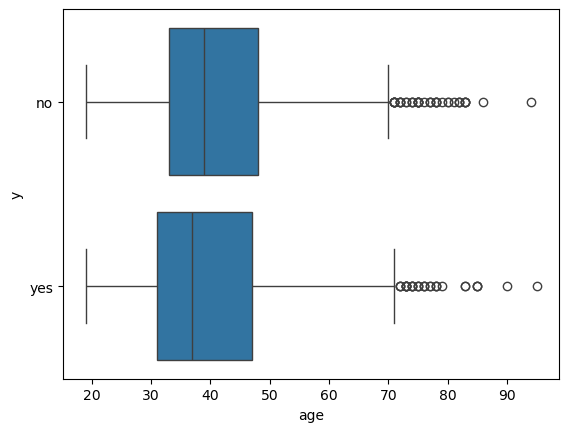

balance:


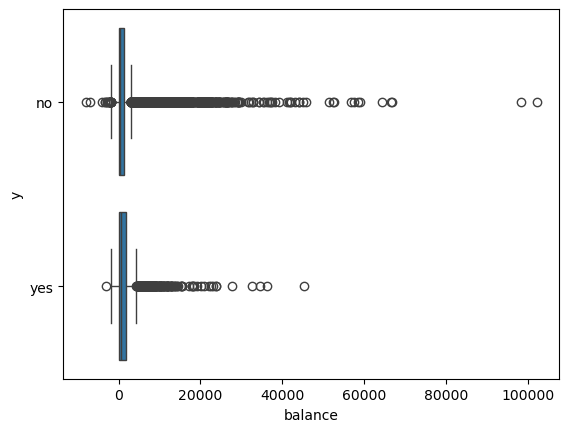

day:


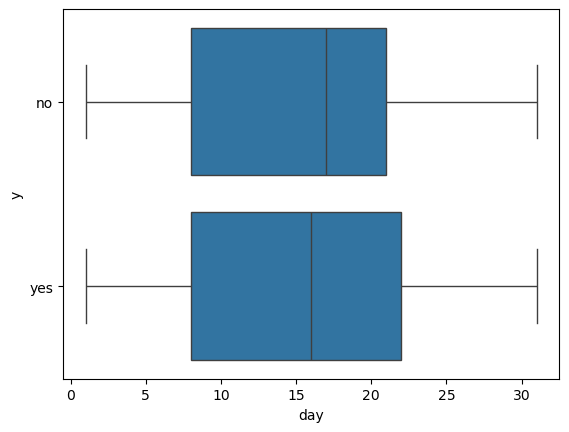

duration:


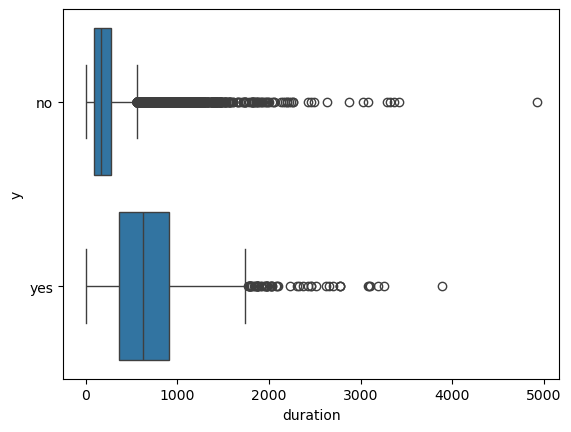

campaign:


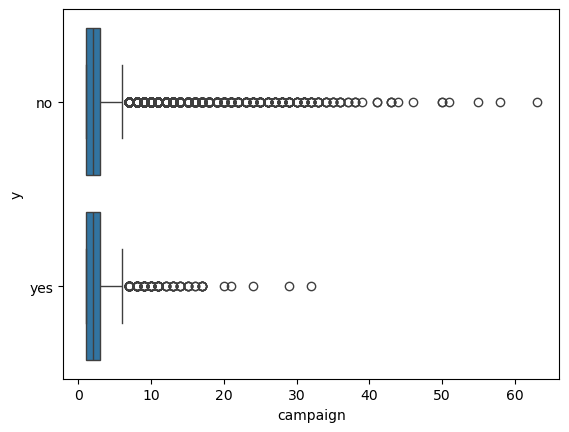

In [18]:
# Numerical features
feats = [feature for feature in df.select_dtypes("int")]

for feat in feats:
    print_bold(f"{feat}:")
    sns.boxplot(data=df, x=feat, y="y")
    plt.show()

**NOTE:**
- Boxplots of the numerical features showed no clear/significant separation between the two classes.

#### Cross val score

In [19]:
# Numerical features - cross val score
feats = [feature for feature in df.select_dtypes("int")]
df_ = df_enc_balanced.copy()

for feat in feats:
    print_bold(feat)
    dtc = DecisionTreeClassifier()
    cross_val = cross_val_score(dtc, df_[[feat]], df_[["y"]], cv=5).mean()
    print(f"Cross val score for {feat}: {cross_val}")
    barrier()

age
Cross val score for age: 0.525034683881197

 <<< -------------------------------------------------- >>> 

balance
Cross val score for balance: 0.5310807810318288

 <<< -------------------------------------------------- >>> 

day
Cross val score for day: 0.5573210185065143

 <<< -------------------------------------------------- >>> 

duration
Cross val score for duration: 0.7446481020354334

 <<< -------------------------------------------------- >>> 

campaign
Cross val score for campaign: 0.5383297494564577

 <<< -------------------------------------------------- >>> 



In [20]:
# Numerical features - cross val score (XGBClassifier)
feats = [feature for feature in df.select_dtypes("int")]
df_ = df_enc_balanced.copy()

for feat in feats:
    print_bold(feat)
    xgb = XGBClassifier()
    cross_val = cross_val_score(xgb, df_[[feat]], df_["y"], cv=5).mean()
    print(f"Cross val score for {feat}: {cross_val}")
    barrier()


age
Cross val score for age: 0.5248601840965277

 <<< -------------------------------------------------- >>> 

balance
Cross val score for balance: 0.5219285579105327

 <<< -------------------------------------------------- >>> 

day
Cross val score for day: 0.5571484559525886

 <<< -------------------------------------------------- >>> 

duration
Cross val score for duration: 0.785741534674195

 <<< -------------------------------------------------- >>> 

campaign
Cross val score for campaign: 0.5385023120103836

 <<< -------------------------------------------------- >>> 



**NOTE:**
- All numerical features, with the exception of `duration`, show a poor cross validated accuracy score when predicting the target feature.

### Categorical

job :


,count,%
job,,
management,679,23.446133
blue-collar,539,18.611878
technician,500,17.265193
admin,352,12.154696
services,240,8.287293
retired,152,5.248619
self-employed,113,3.901934
unemployed,97,3.349448
entrepreneur,89,3.073204


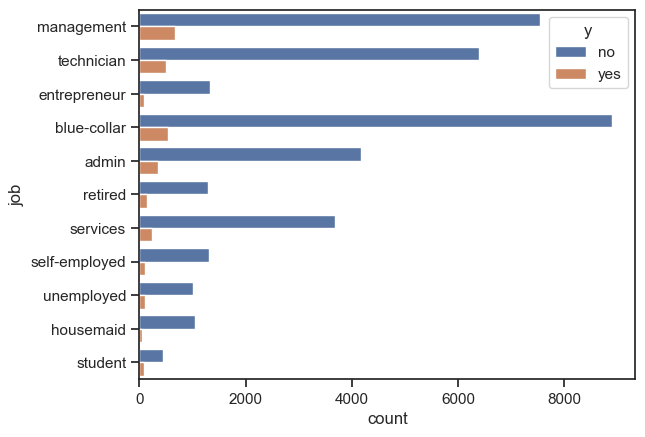


 <<< -------------------------------------------------- >>> 

marital :


,count,%
marital,,
married,1478,51.035912
single,1027,35.462707
divorced,391,13.501381


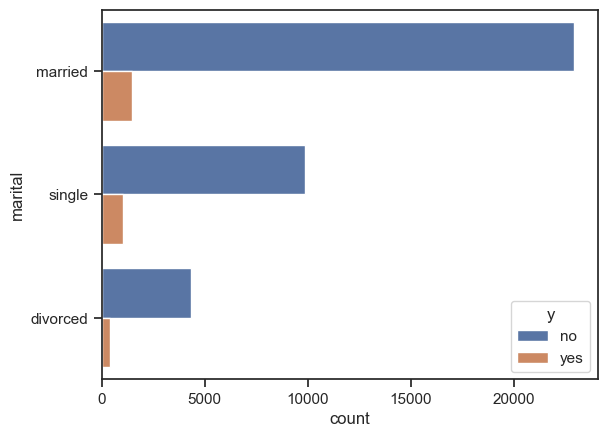


 <<< -------------------------------------------------- >>> 

education :


,count,%
education,,
secondary,1473,50.863260
tertiary,1054,36.395028
primary,369,12.741713


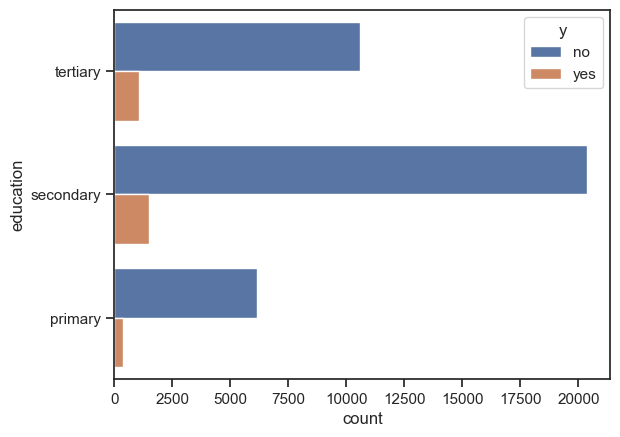


 <<< -------------------------------------------------- >>> 

default :


,count,%
default,,
no,2847,98.308011
yes,49,1.691989


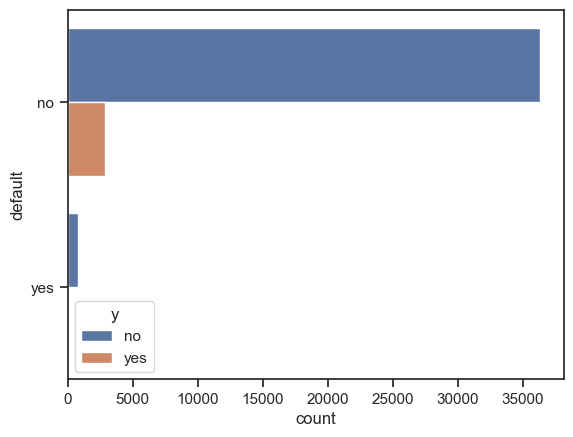


 <<< -------------------------------------------------- >>> 

housing :


,count,%
housing,,
yes,1464,50.552486
no,1432,49.447514


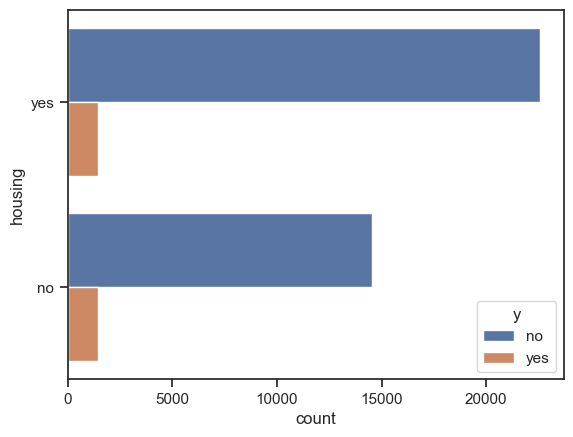


 <<< -------------------------------------------------- >>> 

loan :


,count,%
loan,,
no,2516,86.878453
yes,380,13.121547


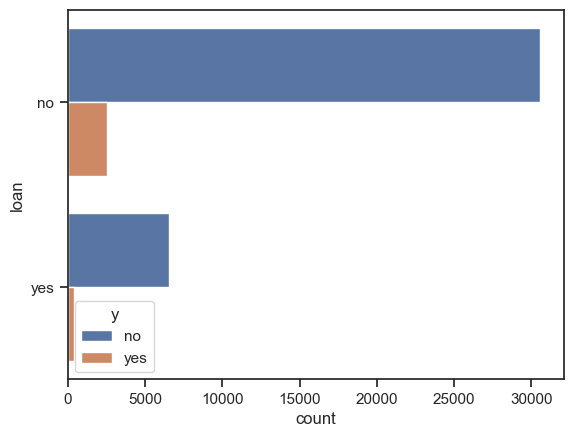


 <<< -------------------------------------------------- >>> 

contact :


,count,%
contact,,
cellular,2694,93.024862
telephone,202,6.975138


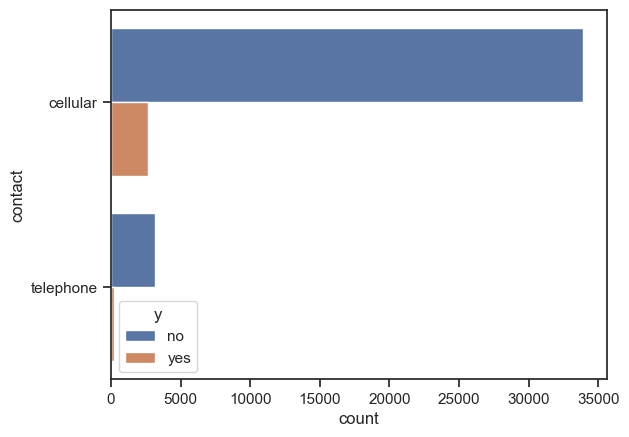


 <<< -------------------------------------------------- >>> 

month :


,count,%
month,,
may,791,27.313536
apr,451,15.573204
jul,384,13.259669
jun,294,10.151934
aug,288,9.944751
feb,255,8.805249
nov,220,7.596685
mar,125,4.316298
oct,49,1.691989


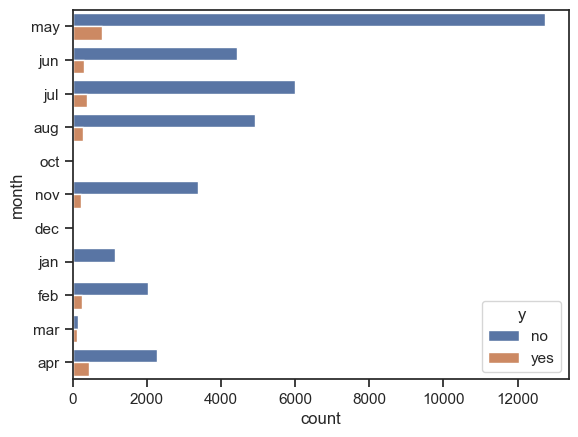


 <<< -------------------------------------------------- >>> 

day :


,count,%
day,,
30,224,7.734807
18,165,5.697514
20,153,5.283149
21,139,4.799724
15,123,4.247238
13,117,4.040055
4,117,4.040055
17,115,3.970994
14,115,3.970994


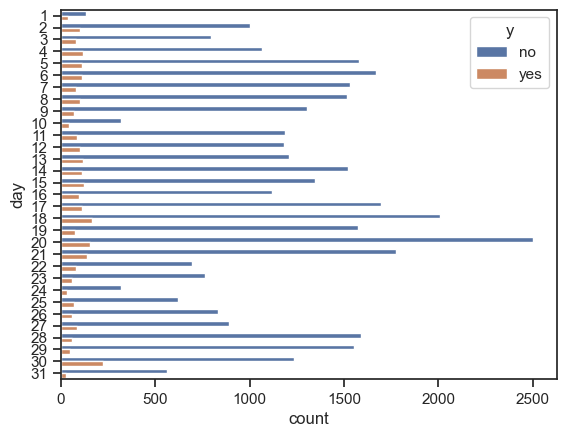


 <<< -------------------------------------------------- >>> 



In [21]:
# Categorical features
feats = [feature for feature in df.select_dtypes("object").columns if feature != "y"]
feats.append("day")

for feat in feats:
    print(bold(feat), ":")
    counts = df_yes[feat].value_counts().rename("count")
    df_ = counts.to_frame()
    df_["%"] = df_["count"] / df_yes.shape[0] * 100
    display(df_)
    sns.set_theme(style="ticks")
    sns.countplot(y=feat, hue="y", data=df)
    plt.show()
    barrier()


In [22]:
# # Categorical features
# feats = [feature for feature in df.select_dtypes("object").columns if feature != "y"]

# for feat in feats:
#     sns.set(style="ticks", color_codes=True)
#     sns.countplot(y=feat, hue="y", data=df)
#     plt.show()

**NOTE:**
- Plots of the features against the target variables seem to suggest that favorable market segments include: **(admin, technician, services, management, blue collar), married, at least secondary school educated, no default, no loan, cellular communicating** customers last called between **April to July** and in **November**.
- The nature of this result would be a topic of conversation during follow up discussions with the client.

#### Cross val score

In [23]:
# Categorical features - cross val score
feats = [feature for feature in df.select_dtypes("object").columns if feature != "y"]
feats.append("day")
df_ = df_enc_balanced.copy()

for feat in feats:
    print_bold(feat)
    dtc = DecisionTreeClassifier()
    cross_val = cross_val_score(dtc, df_[[feat]], df_[["y"]], cv=5).mean()
    print(f"Cross val score for {feat}: {cross_val}")
    barrier()

job
Cross val score for job: 0.5428150346987829

 <<< -------------------------------------------------- >>> 

marital
Cross val score for marital: 0.5538672341262567

 <<< -------------------------------------------------- >>> 

education
Cross val score for education: 0.5452337417909847

 <<< -------------------------------------------------- >>> 

default
Cross val score for default: 0.49758263406754377

 <<< -------------------------------------------------- >>> 

housing
Cross val score for housing: 0.546969500537209

 <<< -------------------------------------------------- >>> 

loan
Cross val score for loan: 0.5276256554918255

 <<< -------------------------------------------------- >>> 

contact
Cross val score for contact: 0.5075955837099757

 <<< -------------------------------------------------- >>> 

month
Cross val score for month: 0.5878812805393251

 <<< -------------------------------------------------- >>> 

day
Cross val score for day: 0.5573210185065143

 <<< --------

In [24]:
# Categorical features - cross val score (XGBClassifier)
feats = [feature for feature in df.select_dtypes("object").columns if feature != "y"]
feats.append("day")
df_ = df_enc_balanced.copy()

for feat in feats:
    print_bold(feat)
    xgb = XGBClassifier()
    cross_val = cross_val_score(xgb, df_[[feat]], df_["y"], cv=5).mean()
    print(f"Cross val score for {feat}: {cross_val}")
    barrier()


job
Cross val score for job: 0.5428150346987829

 <<< -------------------------------------------------- >>> 

marital
Cross val score for marital: 0.5538672341262567

 <<< -------------------------------------------------- >>> 

education
Cross val score for education: 0.5452337417909847

 <<< -------------------------------------------------- >>> 

default
Cross val score for default: 0.49758263406754377

 <<< -------------------------------------------------- >>> 

housing
Cross val score for housing: 0.546969500537209

 <<< -------------------------------------------------- >>> 

loan
Cross val score for loan: 0.5276256554918255

 <<< -------------------------------------------------- >>> 

contact
Cross val score for contact: 0.5075955837099757

 <<< -------------------------------------------------- >>> 

month
Cross val score for month: 0.5878812805393251

 <<< -------------------------------------------------- >>> 

day
Cross val score for day: 0.5571484559525886

 <<< --------

**NOTE:**
- All categorical features show a poor cross validated accuracy score when predicting the target feature.

### Clustering

#### PCA

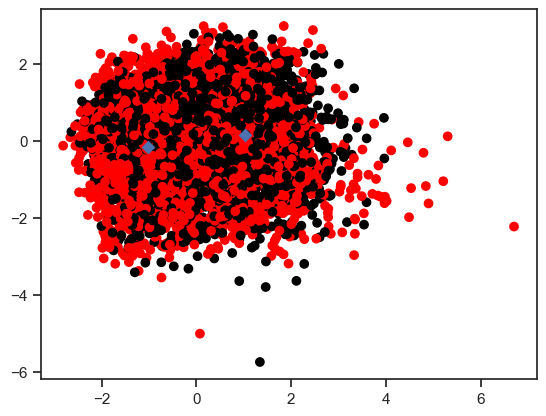

In [25]:
# 2D - Scaling, PCA, KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(2).fit(X_scaled)
X_pca = pca.transform(X_scaled)
model = KMeans(n_clusters=2)
model.fit(X_pca)

# Plot
c = y.replace({0:"black", 1:"red"})
xs = X_pca[:, 0]
ys = X_pca[:, 1]
plt.scatter(xs, ys, c=c)
centroids = model.cluster_centers_
centroids_x = centroids[:, 0]
centroids_y = centroids[:, 1]
plt.scatter(centroids_x, centroids_y, marker="D")
plt.show()

In [26]:
# 3D - Scaling, PCA, KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(3).fit(X_scaled)
X_pca = pca.transform(X_scaled)
model = KMeans(n_clusters=2)
model.fit(X_pca)

# Plot
c = y.replace({0:"no", 1:"yes"})
xs = X_pca[:, 0]
ys = X_pca[:, 1]
zs = X_pca[:, 2]
fig = px.scatter_3d(x=xs, y=ys, z=zs, color=c)
fig.show()

#### TSNE

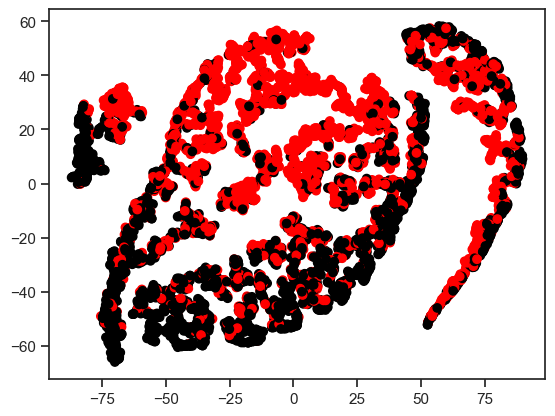

In [27]:
# 2D - TSNE
model = TSNE(learning_rate=200)
tsne_features = model.fit_transform(X)
xs = tsne_features[:, 0]
ys = tsne_features[:, 1]
c = y.replace({0:"black", 1:"red"})
plt.scatter(xs, ys, c=c)
plt.show()

In [28]:
# 3D - TSNE
model = TSNE(learning_rate=200, n_components=3)
tsne_features = model.fit_transform(X)
xs = tsne_features[:, 0]
ys = tsne_features[:, 1]
zs = tsne_features[:, 2]
c = y.replace({0:"no", 1:"yes"})
fig = px.scatter_3d(x=xs, y=ys, z=zs, color=c)
fig.show()

**NOTE:**
- 2D and 3D plots of the dataset using both **PCA feature reduction** and **TSNE feature reduction** show no linear separability.
- No further insight was provided by clustering.

## Final conclusion & Inference

**Feature importance:**
- Across all methods and models, there are clearly significant variations in feature importance.
- The most standout **numerical** feature appear to be `duration` by a significant margin.
- The features `month`, `day`, `housing`, `balance`, `age` also show importance to a lesser but still significant degree.
- This was further bolstered by the result of using cross validation scores (in the Customer segmentation section) calculated using each feature individually to predict the target variable.
    - Here, only the `duration` feature (**~74% accuracy**) showed a result that was significantly better than random guessing (50% accuracy).
- At the same time, the categorical feature analysis suggested that the favorable market segments include: **(admin, technician, services, management, blue collar), married, at least secondary school educated, no default, no loan, cellular communicating** customers last called between **April to July** and in **November**.
- The nature of this result would be a topic of conversation during follow up discussions with the client.

**Customer segmentation:**
- The box plots of the numerical features showed no clear separation/distinction with regards to the likelihood of subscribing to a term deposit.

**Clustering:**
- The data was reduced using both PCA and TSNE into both 2D and 3D datasets.
- In each case, the data was was then clustered and plotted but there was no clear separation/distinction with regards to the likelihood of subscribing to a term deposit.

**See notebook_1.ipynb for:**
- Data wrangling
- Exploratory Data Analysis
- Data visualization
- Preprocessing and Training
- Modeling